In [153]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from skimage.morphology import skeletonize

In [7]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [8]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


In [11]:
def convert_to_greyscale(img):
    grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Display output image
    plt.figure(figsize=(6,6))
    plt.imshow(grey, cmap='gray')
    plt.title("Greyscale Output")
    plt.axis('off')

    return grey

In [12]:
def enhance_contrast(img):
    """
    Linear contrast stretching using 2nd–98th percentiles.
    Works well on aerial parking images.
    Accepts grayscale or BGR numpy arrays.
    """

    # If it's color (BGR), convert to YCrCb for luminance-only stretching
    if len(img.shape) == 3:
        ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        y = ycrcb[:, :, 0]

        # Percentile-based contrast stretch
        p2, p98 = np.percentile(y, (2, 98))
        y_stretched = np.clip((y - p2) * 255.0 / (p98 - p2), 0, 255).astype(np.uint8)

        ycrcb[:, :, 0] = y_stretched
        out = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

    else:  # grayscale
        p2, p98 = np.percentile(img, (2, 98))
        out = np.clip((img - p2) * 255.0 / (p98 - p2), 0, 255).astype(np.uint8)

    # Display result
    plt.figure(figsize=(6,6))
    if len(out.shape) == 2:
        plt.imshow(out, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    plt.title("Contrast Enhanced")
    plt.axis("off")

    return out

In [13]:
def blur_image(img, method="gaussian", k=9):
    """
    Blur the image to reduce noise before edge detection.
    method: "gaussian" (default) or "median" or "bilateral"
    k: kernel size (must be odd)
    
    Accepts grayscale or BGR numpy arrays.
    """

    # --- Gaussian Blur (recommended for this project) ---
    if method == "gaussian":
        blurred = cv2.GaussianBlur(img, (k, k), sigmaX=0)

    # --- Median Blur (robust to speckle + shadows) ---
    elif method == "median":
        blurred = cv2.medianBlur(img, k)

    # --- Bilateral (best detail preservation, slow) ---
    elif method == "bilateral":
        blurred = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

    else:
        raise ValueError("Unknown blur method")

    # Display
    plt.figure(figsize=(6,6))
    if len(blurred.shape) == 2:
        plt.imshow(blurred, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
    plt.title(f"Blurred ({method})")
    plt.axis("off")

    return blurred

In [14]:
def edge_detection(img, use_automatic=True, low=50, high=150):
    """
    Perform Canny edge detection.
    
    If use_automatic=True:
        Automatically computes thresholds based on image statistics.
    Otherwise:
        Uses manual low/high thresholds.
    """

    # Ensure grayscale
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img

    # --- Automatic thresholding (recommended) ---
    if use_automatic:
        # Compute Otsu threshold
        otsu_thresh, _ = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Canny thresholds relative to Otsu value
        low_t  = max(5, 0.5 * otsu_thresh)
        high_t = min(255, 1.5 * otsu_thresh)
    else:
        low_t, high_t = low, high

    edges = cv2.Canny(img_gray, int(low_t), int(high_t))

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(edges, cmap='gray')
    plt.title(f"Canny Edges (low={int(low_t)}, high={int(high_t)})")
    plt.axis("off")

    return edges


In [17]:
def compute_gradients(img):
    """
    Compute Sobel gradients in X and Y directions.
    Returns (gx, gy, magnitude, direction).
    Accepts grayscale or BGR numpy arrays.
    """

    # Ensure grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # Sobel gradients
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    # Magnitude + direction
    mag = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)  # radians

    # Normalize magnitude for display
    mag_disp = (mag / mag.max() * 255).astype(np.uint8)

    # Display (magnitude only)
    plt.figure(figsize=(6,6))
    plt.imshow(mag_disp, cmap='gray')
    plt.title("Gradient Magnitude")
    plt.axis("off")

    return gx, gy, mag, direction


In [52]:
def edge_enhancement(img_gradients, original_img, alpha=0.7):
    """
    Enhance edges by adding normalized gradient magnitude back to the image.

    img_gradients: tuple returned by compute_gradients() → (gx, gy, mag, direction)
    original_img:  the blurred grayscale or BGR image (before gradients)
    alpha:         strength of sharpening (0.3–1.0 works well)
    """

    gx, gy, mag, direction = img_gradients

    # Ensure grayscale for enhancement
    if len(original_img.shape) == 3:
        gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = original_img

    mag_norm = np.uint8(255 * (mag / (mag.max() + 1e-6)))

    sharpened = gray.astype(np.float32) + alpha * mag_norm.astype(np.float32)
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(sharpened, cmap="gray")
    plt.title(f"Edge Enhanced (alpha={alpha})")
    plt.axis("off")

    return sharpened


In [30]:
def detect_lines(img_edges, min_line_length=50, max_line_gap=10):
    """
    Probabilistic Hough Line Transform.
    Input: Canny edge image (binary)
    Returns: list of lines, each line = (x1, y1, x2, y2)
    """

    lines = cv2.HoughLinesP(
        img_edges,
        rho=1,
        theta=np.pi / 180,
        threshold=50,
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    # For display, overlay on RGB version
    disp = cv2.cvtColor(img_edges, cv2.COLOR_GRAY2RGB)

    if lines is not None:
        for (x1, y1, x2, y2) in lines[:, 0]:
            cv2.line(disp, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(disp)
    plt.title("Detected Lines (Hough)")
    plt.axis("off")

    return lines


In [31]:
def detect_corners(img, method="shi", max_corners=500):
    """
    Detect corners using Harris or Shi-Tomasi.
    Input: grayscale or BGR image
    Returns: array of corner points
    """

    # Ensure grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    if method == "shi":
        corners = cv2.goodFeaturesToTrack(
            gray,
            maxCorners=max_corners,
            qualityLevel=0.01,
            minDistance=5
        )
    elif method == "harris":
        gray_float = np.float32(gray)
        harris = cv2.cornerHarris(gray_float, 2, 3, 0.04)
        harris = cv2.dilate(harris, None)
        corners = np.argwhere(harris > 0.01 * harris.max())
    else:
        raise ValueError("method must be 'shi' or 'harris'")

    # Display
    disp = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

    if corners is not None:
        if method == "shi":
            for c in corners:
                x, y = c.ravel()
                cv2.circle(disp, (int(x), int(y)), 3, (0, 255, 0), -1)
        else:  # Harris output has different format
            for y, x in corners:
                cv2.circle(disp, (int(x), int(y)), 3, (255, 0, 0), -1)

    plt.figure(figsize=(6,6))
    plt.imshow(disp)
    plt.title(f"Corners ({method})")
    plt.axis("off")

    return corners


In [32]:
def detect_local_features(img):
    """
    Detect SIFT keypoints and descriptors.
    Input: grayscale or BGR
    Returns: keypoints, descriptors
    """

    # Ensure grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    # Display
    disp = cv2.drawKeypoints(gray, keypoints, None,
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    plt.figure(figsize=(6,6))
    plt.imshow(disp, cmap='gray')
    plt.title("SIFT Keypoints")
    plt.axis("off")

    return keypoints, descriptors


In [37]:
def find_parking_zones(lines, corners, img_shape=None, min_corners=20):
    """
    Classical parking-zone extractor.
    Input:
        lines   = output from HoughLinesP (x1,y1,x2,y2)
        corners = corner list from detect_corners()
        img_shape = (H,W)
    Output:
        List of zones as (x1,y1,x2,y2) bounding boxes
    """

    if lines is None or len(lines) == 0:
        return []

    # --- STEP 1: Extract angles of all lines ---
    angles = []
    line_segments = []
    for l in lines[:,0]:
        x1,y1,x2,y2 = l
        angle = math.degrees(math.atan2((y2-y1),(x2-x1)))
        angle = angle % 180                 # wrap to [0,180)
        if angle > 90:                      # make parallel groups symmetric
            angle = angle - 180
        angle = abs(angle)                  # now 0° = horizontal, ~90° = vertical
        angles.append(angle)
        line_segments.append((x1,y1,x2,y2))

    angles = np.array(angles)

    # --- STEP 2: Classical Histogram binning of angles (no ML) ---
    # Histogram of 180 bins (1° each)
    hist, bins = np.histogram(angles, bins=180, range=(0,90))

    # Find top 2 dominant angle ranges
    dom1 = np.argmax(hist)
    hist[dom1] = 0    # zero out to find second peak
    dom2 = np.argmax(hist) if hist.max() > 0 else None

    dominant_angles = [dom1]
    if dom2 is not None:
        dominant_angles.append(dom2)

    # --- STEP 3: Group lines by dominant angle bins ---
    groups = {a: [] for a in dominant_angles}

    for ang, seg in zip(angles, line_segments):
        # Assign to closest dominant angle bin
        best_bin = min(dominant_angles, key=lambda d: abs(d - ang))
        groups[best_bin].append(seg)

    # --- STEP 4: Build bounding boxes for each orientation group ---
    candidate_boxes = []

    for a, group in groups.items():
        if len(group) < 3:
            continue

        xs = []
        ys = []
        for (x1,y1,x2,y2) in group:
            xs += [x1, x2]
            ys += [y1, y2]

        x1, x2 = min(xs), max(xs)
        y1, y2 = min(ys), max(ys)

        # Expand slightly
        pad = 10
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = x2 + pad
        y2 = y2 + pad

        candidate_boxes.append((x1, y1, x2, y2))

    # --- STEP 5: Validate boxes using corner density ---
    final_boxes = []
    for (x1,y1,x2,y2) in candidate_boxes:
        # Count corners inside bounding box
        if corners is None:
            continue
        count = 0
        for c in corners:
            x,y = int(c[0][0]), int(c[0][1])
            if x1 <= x <= x2 and y1 <= y <= y2:
                count += 1

        # Keep only boxes with good structure
        if count >= min_corners:
            final_boxes.append((x1,y1,x2,y2))

    # --- STEP 6: Merge overlapping boxes ---
    merged = merge_overlapping_boxes(final_boxes)

    return merged


def merge_overlapping_boxes(boxes, overlap_thresh=0.4):
    """
    Merge overlapping bounding boxes.
    Classical IoU-based merging.
    """
    if len(boxes) == 0:
        return []

    merged = []
    used = [False]*len(boxes)

    def iou(a,b):
        ax1,ay1,ax2,ay2 = a
        bx1,by1,bx2,by2 = b
        inter_x1 = max(ax1,bx1)
        inter_y1 = max(ay1,by1)
        inter_x2 = min(ax2,bx2)
        inter_y2 = min(ay2,by2)

        if inter_x2 < inter_x1 or inter_y2 < inter_y1:
            return 0.0

        inter = (inter_x2-inter_x1)*(inter_y2-inter_y1)
        area_a = (ax2-ax1)*(ay2-ay1)
        area_b = (bx2-bx1)*(by2-by1)
        return inter / float(area_a+area_b-inter)

    for i in range(len(boxes)):
        if used[i]:
            continue
        boxA = boxes[i]
        for j in range(i+1, len(boxes)):
            if used[j]:
                continue
            boxB = boxes[j]
            if iou(boxA, boxB) > overlap_thresh:
                # Merge B into A
                ax1,ay1,ax2,ay2 = boxA
                bx1,by1,bx2,by2 = boxB
                boxA = (min(ax1,bx1), min(ay1,by1), max(ax2,bx2), max(ay2,by2))
                used[j] = True
        used[i] = True
        merged.append(boxA)

    return merged


In [42]:
def print_zones(parking_zones, img):
    """
    Display each parking zone (cropped) in a grid.
    parking_zones: list of (x1, y1, x2, y2)
    img: input image (numpy or PIL)
    """

    # Convert PIL → numpy if needed
    if isinstance(img, Image.Image):
        img_np = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    else:
        img_np = img.copy()

    cropped_list = []

    n = len(parking_zones)
    if n == 0:
        print("No parking zones detected.")
        return []

    # Compute grid size (square-ish layout)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4*cols, 4*rows))

    for i, (x1, y1, x2, y2) in enumerate(parking_zones):

        # Crop region
        crop = img_np[y1:y2, x1:x2]
        cropped_list.append(crop)

        # Show it
        plt.subplot(rows, cols, i+1)
        plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        plt.title(f"Zone {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return cropped_list


In [57]:
def mask_or_binarise(img):
    """
    Produce a clean binary mask from a sharpened grayscale image.
    Uses adaptive thresholding + morphological cleanup.
    Input: grayscale or sharpened grayscale image.
    Output: binary mask (0/255)
    """

    # Ensure grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # --- Adaptive binarisation ---
    binary = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=31,       # adaptive window size
        C=5                 # constant subtraction
    )

    # --- Clean mask ---
    kernel = np.ones((3,3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Show result
    plt.figure(figsize=(6,6))
    plt.imshow(binary, cmap="gray")
    plt.title("Binary Mask / Threshold Output")
    plt.axis("off")

    return binary

In [143]:
def remove_large_white_components(mask, max_area=10000):
    """
    Removes very large white connected components by turning them black.
    mask: binary image with white=foreground, black=background
    max_area: any white component larger than this becomes black
    """

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    cleaned = mask.copy()

    for i in range(1, num_labels):  # skip background
        area = stats[i, cv2.CC_STAT_AREA]

        if area > max_area:
            cleaned[labels == i] = 0    # paint huge white region black

    # Display result
    plt.figure(figsize=(6,6))
    plt.imshow(cleaned, cmap="gray")
    plt.title(f"Removed Large White Regions (>{max_area} px)")
    plt.axis("off")

    return cleaned

In [144]:
def enhance_paint_lines(img_eq):
    """
    Extract bright painted lines (stall lines, arrows) using
    a white top-hat transform + Otsu thresholding.
    Input: img_eq = enhanced-contrast grayscale image.
    Output: binary mask containing ONLY painted lines.
    """

    # Ensure grayscale
    if len(img_eq.shape) == 3:
        gray = cv2.cvtColor(img_eq, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_eq

    # --- 1. White top-hat transform ---
    # Kernel size should be larger than the width of parking lines
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel)

    # --- 2. Otsu threshold ---
    _, mask = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # --- 3. Morphological cleaning ---
    k2 = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k2, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k2, iterations=1)

    # Display result
    plt.figure(figsize=(6,6))
    plt.imshow(mask, cmap='gray')
    plt.title("Enhanced Painted Lines")
    plt.axis("off")

    return mask

In [390]:
def erode(mask, ksize=4, iterations=1):

    # Erode inverted image = shrink black regions in original
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    eroded = cv2.erode(mask, kernel, iterations)

    # Display
    plt.figure(figsize=(6,6))
    plt.imshow(eroded, cmap="gray")
    plt.title(f"Erosion (ksize={ksize})")
    plt.axis("off")

    return eroded

In [391]:
def skeletonize_lines(mask):
    # mask = 0/255
    binary = (mask > 0).astype(np.uint8)
    skel = skeletonize(binary).astype(np.uint8) * 255

    plt.figure(figsize=(6,6))
    plt.imshow(skel, cmap="gray")
    plt.title("Skeletonized Lines")
    plt.axis("off")
    
    return skel

In [392]:
def thicken_lines(mask, ksize=5):
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, ksize))
    thick = cv2.dilate(mask, kernel, iterations=1)
    #smoothed = cv2.GaussianBlur(thick, (9,9), 0)
    plt.figure(figsize=(6,6))
    plt.imshow(thick, cmap="gray")
    plt.title("Thickened Lines + Smoothed")
    plt.axis("off")
    
    return thick

In [393]:
def detect_hough_lines(mask, rho=1, theta=np.pi/180, threshold=150):
    """
    Detects infinite Hough lines (not segments) from a binary mask.
    Returns a list of (rho, theta) pairs.
    """

    # Hough expects edges or thin bright strokes → thick_lines is perfect
    lines = cv2.HoughLines(mask, rho, theta, threshold)

    # Display visualization
    vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    if lines is not None:
        for line in lines:
            rho, theta = line[0]

            # convert polar -> line endpoints for drawing
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho

            # two far-away points
            x1 = int(x0 + 2000 * (-b))
            y1 = int(y0 + 2000 * (a))
            x2 = int(x0 - 2000 * (-b))
            y2 = int(y0 - 2000 * (a))

            cv2.line(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Standard Hough Lines (Infinite Lines)")
    plt.axis("off")

    return lines

In [394]:
def draw_hough_lines(lines, mask, color=(0,0,255), thickness=2):
    """
    Draws infinite Hough lines returned by cv2.HoughLines onto a copy of the mask.
    lines: result of cv2.HoughLines (rho, theta pairs)
    mask: binary mask used to detect lines (for sizing)
    """

    # convert mask to BGR for colored lines
    vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

    if lines is not None:
        for line in lines:
            rho, theta = line[0]

            # convert polar → cartesian line representation
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho

            # two far points along the line direction
            x1 = int(x0 + 2000 * (-b))
            y1 = int(y0 + 2000 * (a))
            x2 = int(x0 - 2000 * (-b))
            y2 = int(y0 - 2000 * (a))

            # draw line
            cv2.line(vis, (x1, y1), (x2, y2), color, thickness)

    # show image
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Hough Infinite Lines")
    plt.axis("off")

    return vis


In [400]:
def hough_lines_to_mask(lines, shape, thickness=2):
    """
    Converts infinite Hough lines (rho, theta) into a binary mask
    of drawn lines. Used for intersection with the thick_lines mask.
    """

    h, w = shape
    out = np.zeros((h, w), dtype=np.uint8)

    if lines is None:
        return out

    for line in lines:
        rho, theta = line[0]

        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho

        # Two far-apart points to define full line
        x1 = int(x0 + 2000 * (-b))
        y1 = int(y0 + 2000 * (a))
        x2 = int(x0 - 2000 * (-b))
        y2 = int(y0 - 2000 * (a))

        cv2.line(out, (x1, y1), (x2, y2), 255, thickness)

    return out

In [401]:
def intersect_hough_with_mask(hough_mask, thick_lines):
    """
    Keep only pixels where both the thick line mask and Hough lines overlap.
    This trims infinite lines down to actual parking lines.
    """

    # binary AND
    intersection = cv2.bitwise_and(hough_mask, thick_lines)

    plt.figure(figsize=(6,6))
    plt.imshow(intersection, cmap="gray")
    plt.title("Finite Parking Lines (Hough ∩ ThickLines)")
    plt.axis("off")

    return intersection

In [410]:
def get_line_segments(mask, min_length=30):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    segments = []
    for c in contours:
        if len(c) < min_length:
            continue

        # Fit a line exactly along the segment
        vx, vy, cx, cy = cv2.fitLine(c, cv2.DIST_L2, 0, 0.01, 0.01)
        vx, vy, cx, cy = float(vx), float(vy), float(cx), float(cy)

        # endpoints
        x, y, w, h = cv2.boundingRect(c)
        p1 = (x, y+h//2)
        p2 = (x+w, y+h//2)

        segments.append({
            "contour": c,
            "vx": vx, "vy": vy,
            "cx": cx, "cy": cy,
            "bbox": (x, y, w, h)
        })

    return segments

In [414]:
def segment_angle(seg):
    return np.degrees(np.arctan2(seg["vy"], seg["vx"]))

In [415]:
def cluster_by_orientation(segments, threshold=20):
    long_lines = []
    perp_lines = []

    for s in segments:
        angle = segment_angle(s)

        # Normalize angle to [-90,90] range
        angle = (angle + 180) % 180
        if angle > 90:
            angle -= 180

        if abs(angle) < threshold:
            long_lines.append(s)
        else:
            perp_lines.append(s)

    return long_lines, perp_lines

In [ ]:
def sort_dividers(dividers, direction='horizontal'):
    if direction == 'horizontal':
        return sorted(dividers, key=lambda s: s["bbox"][0])  # sort by x
    else:
        return sorted(dividers, key=lambda s: s["bbox"][1])  # sort by y

In [ ]:
def make_parking_spots(dividers, row_height=40):
    spots = []

    for i in range(len(dividers)-1):
        x1 = dividers[i]["bbox"][0]
        x2 = dividers[i+1]["bbox"][0]

        # use the average y of row lines as top/bottom
        # but for now assume row spans whole height of dividers
        y = min(dividers[i]["bbox"][1], dividers[i+1]["bbox"][1])
        h = max(dividers[i]["bbox"][3], dividers[i+1]["bbox"][3])

        spots.append((x1, y, x2-x1, h))

    return spots


In [416]:
# Function to do the pipeline on the whole image.
def do_pipeline(img):

    # PREPROCESSING
    img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    img_grey = convert_to_greyscale(img)
    img_eq   = enhance_contrast(img_grey)
    img_blur = blur_image(img_eq, "bilateral")

    # FEATURE
    #img_edges     = edge_detection(img_blur)            # Canny
    gx, gy, mag, direction = compute_gradients(img_blur)
    img_sharpened = edge_enhancement((gx, gy, mag, direction), img_blur, alpha=0.9)
    img_mask = mask_or_binarise(img_sharpened)
    eroded = erode(img_mask)
    #thick_lines = thicken_lines(img_mask)
    removed_background = remove_large_white_components(eroded, max_area=5000)
    skel = skeletonize_lines(removed_background)
    thick_lines = thicken_lines(skel)

    hough_lines = detect_hough_lines(skel)
    sanity = draw_hough_lines(hough_lines, thick_lines)
    hough_mask = hough_lines_to_mask(hough_lines, thick_lines.shape)
    finite_lines = intersect_hough_with_mask(hough_mask, thick_lines)
    
    # --- Get Line Coordinates ---
    segments = get_line_segments(finite_lines)
    row_lines, dividers = cluster_by_orientation(segments)
    # straight_lines = straighten_with_hough(thick_lines)
    # lines = detect_lines(img_edges)                     # Hough Transform
    #corners = detect_corners(img_sharpened)                    # Harris / Shi-Tomasi
    # features = detect_local_features(img_sharpened)            # SIFT/SURF (optional)

    # --- PARKING ZONE / ROI EXTRACTION ---
    # parking_zones = find_parking_zones(lines, corners)
    # zone_imgs = print_zones(parking_zones, img)

    # --- PROCESS EACH PARKING ZONE ---
    # all_spots = []
    # for zone in parking_zones:

    #     zone_img = crop_zone(img, zone)

    #     # geometric structure inside zone
    #     zone_lines = detect_lines(zone_img)
    #     spot_candidates = segment_parking_spots(zone_img, zone_lines)

    #     # refine candidate spots
    #     refined_spots = filter_and_validate_spots(spot_candidates)

    #     all_spots.extend(refined_spots)

    # # --- OCCUPANCY CLASSIFICATION ---
    # results = []
    # for spot in all_spots:

    #     spot_img = crop_spot(img, spot)

    #     # preprocessing per spot
    #     spot_gray = convert_to_grayscale(spot_img)
    #     spot_eq   = enhance_contrast(spot_gray)

    #     # detect if car is present
    #     occupancy_features = extract_occupancy_features(spot_eq)
    #     occupied = classify_occupancy(occupancy_features)

    #     results.append((spot, occupied))

    # # --- VISUALISATION OF OUTPUT ---
    # output_img = draw_detected_spots(img, results)

    return #results, output_img

/tmp/ipykernel_98519/535769252.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vx, vy, cx, cy = float(vx), float(vy), float(cx), float(cy)


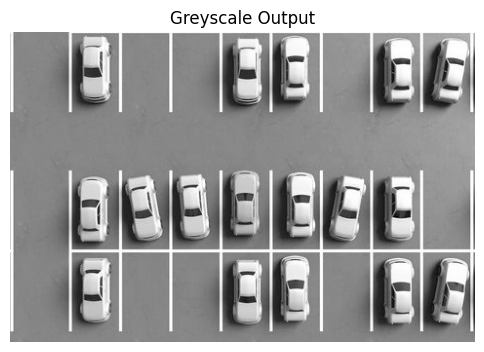

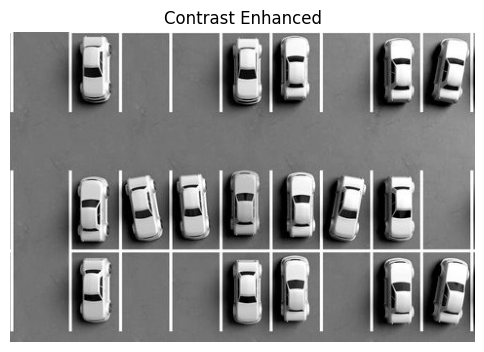

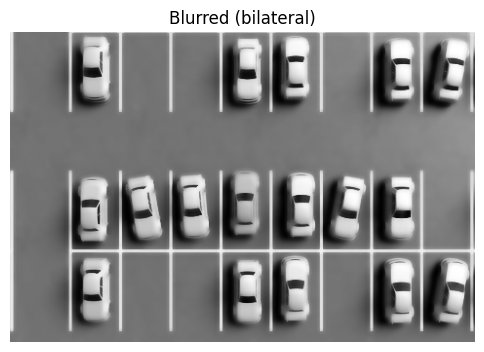

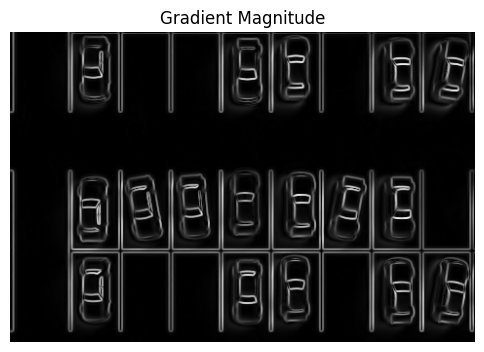

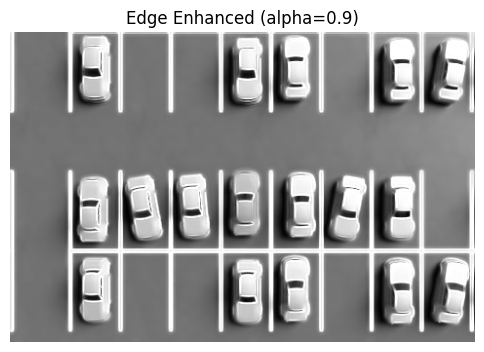

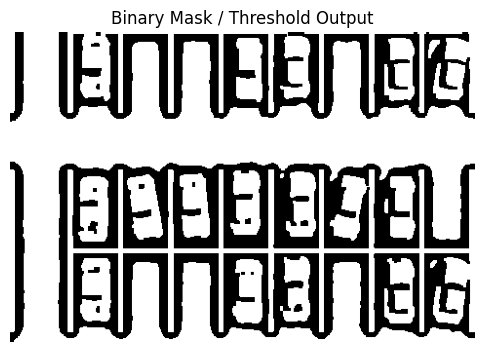

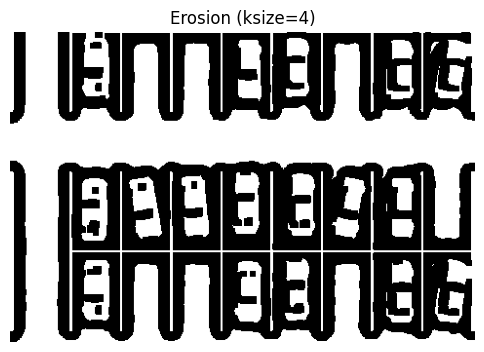

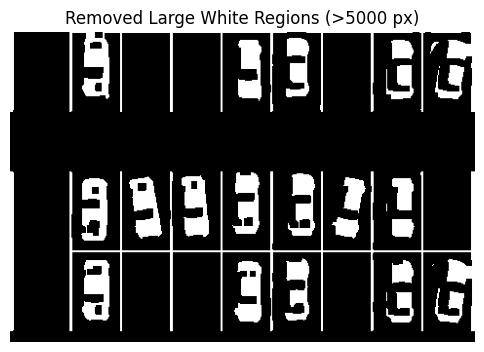

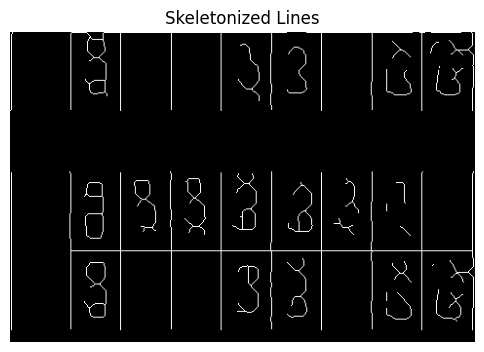

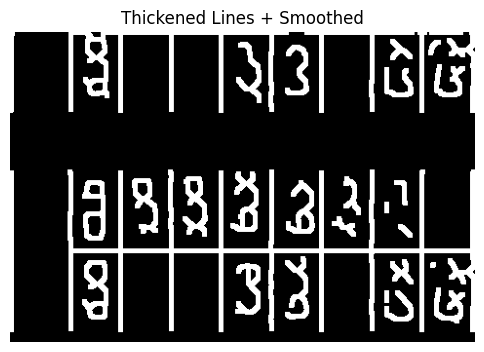

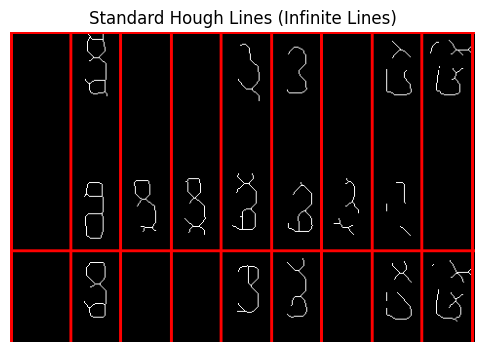

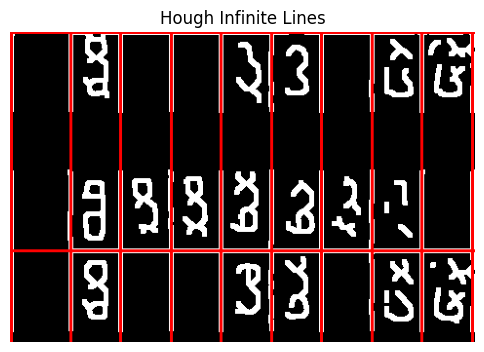

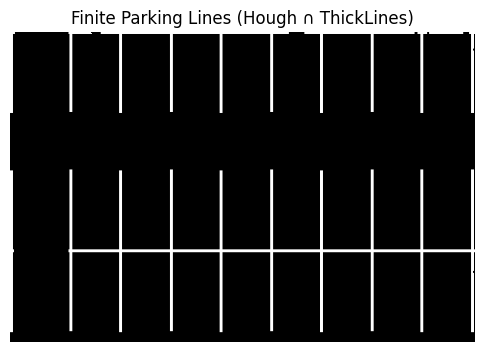

In [409]:
do_pipeline(images["easy"]["29.png"])
#do_pipeline(images["hard"]["21.png"])
#do_pipeline(images["hard"]["frame600.jpg"])